## Simulating the dataset

Runs in the **eztao** environment. Imports `LightCurves` only; never touches jax. The `.npz`
files written at the end are the entire interface to the training side, so the two environments
never have to agree on numpy, matplotlib or scipy versions.

Figures here justify the simulation *design*; results figures live in Stage 1.

In [7]:
%load_ext autoreload
%autoreload 2
import numpy as np, matplotlib.pyplot as plt, os
from Style import useAA
from LightCurves import MultibandLCGenerator, makeDataset, saveDataset, plotLC

useAA()
DATA = "/Users/anacecilialr/GitHub/MASS/MASS-Thesis/data"
os.makedirs(DATA, exist_ok=True)

# Yu+25 fiducial g-band driver, 3-year baseline
TAU, SIG, TMAX = 100.0, 0.112, 365*3
NOBS, GAPFRAC, NGAPS = 130, 0.35, 3

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Is the experiment worth running?

`checkRegime` before generating, not after. Gap-filling difficulty is controlled by a single
dimensionless quantity, $\Delta t/\tau$, because a DRW forgets as $e^{-\Delta t/\tau}$ — so the
cadence and the gaps only mean anything relative to $\tau$. **These three numbers are quotable in
the thesis**, and they replace "we chose these values".

In [8]:
gen = MultibandLCGenerator(bands="g", t_max=TMAX, tau_driver=TAU, sigma_driver=SIG)
gen.describe(); print()
gen.checkRegime(n_obs=NOBS, gap_frac=GAPFRAC, n_gaps=NGAPS)

Simulated bands = 1: g
Driver band = g
Driver sigma = 0.112
Driver tau = 100.0
Driver snr = 1000000.0
Baseline = 1095 d = 10.9 tau

mean cadence =   8.42 d = 0.084 tau
mean gap     = 127.75 d = 1.28 tau
baseline     =   1095 d = 10.9 tau
epochs kept  ~ 84 of 130 attempted


## 2. Generate

In [9]:
train_c, val_c = makeDataset(
    n_curves=5000, val_frac=0.2, seed0=0,
    gen_kwargs=dict(bands="g", t_max=TMAX, tau_driver=TAU, sigma_driver=SIG),
    lc_kwargs=dict(n_obs=NOBS, gap_frac=GAPFRAC, n_gaps=NGAPS, sigma_phot=0.01),
)
n = np.array([c["t_obs"].size for c in train_c])
print(f"{len(train_c)} train / {len(val_c)} val")
print(f"epochs per curve: {n.min()}-{n.max()} (mean {n.mean():.0f}); "
      f"predicted n_obs*(1-gap_frac) = {NOBS*(1-GAPFRAC):.0f}")

4000 train / 1000 val
epochs per curve: 64-108 (mean 84); predicted n_obs*(1-gap_frac) = 84


## 3. Example curves

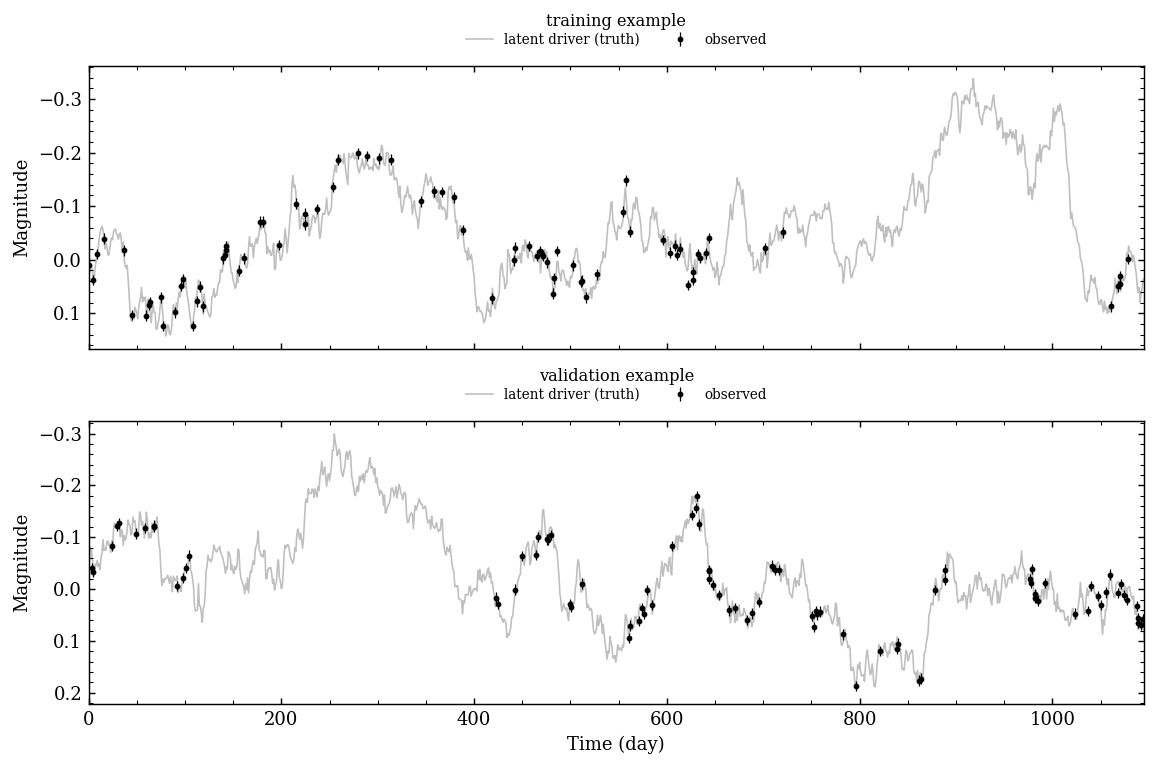

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
plotLC(train_c[0], ax=axes[0])
plotLC(val_c[0],   ax=axes[1])
axes[0].set_title("training example", fontsize=9, pad=22)
axes[1].set_title("validation example", fontsize=9, pad=22)
axes[0].set_xlabel("")
plt.tight_layout(); plt.show()

## 4. Check parameter choises

the **bulk** near $0.08\,\tau$ is the cadence — consecutive epochs strongly correlated;
the **tail** past $\sim\!1\,\tau$ is the gaps — where the DRW has forgotten and reconstruction becomes genuinely hard.

If the tail did not reach $\sim\!\tau$, every gap would be trivially interpolable and the thesis
would have no subject. If the bulk sat past $\tau$, consecutive epochs would be uncorrelated and
nothing could be interpolated at all.

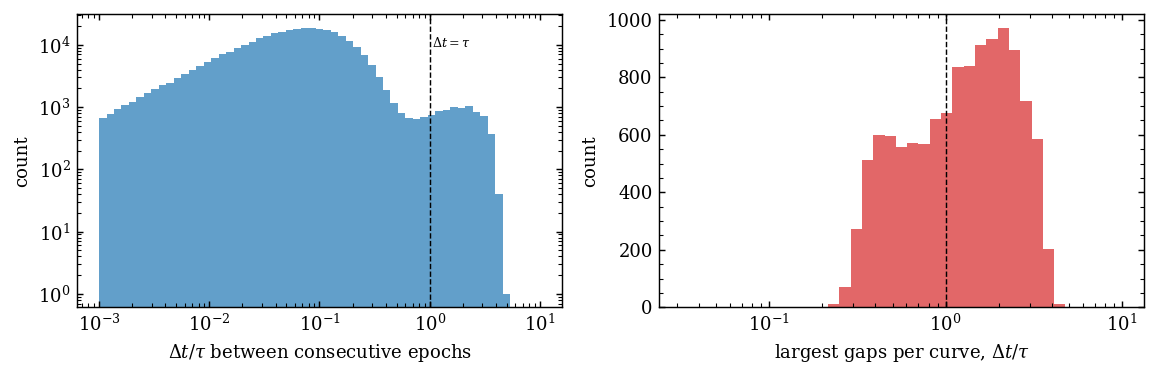

all spacings : median 0.059 tau, 99th pct 1.99 tau
largest gaps : [0.36 1.28 3.21] tau  (5/50/95 pct)
fraction of spacings above 1 tau: 2.2%


In [11]:
dts = np.concatenate([np.diff(c["t_obs"]) / c["tau"] for c in train_c])

fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].hist(dts, bins=np.logspace(-3, 1, 60), color="tab:blue", alpha=.7)
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].axvline(1.0, color="k", ls="--", lw=.8)
ax[0].text(1.05, ax[0].get_ylim()[1]*.3, r"$\Delta t=\tau$", fontsize=7)
ax[0].set_xlabel(r"$\Delta t/\tau$ between consecutive epochs"); ax[0].set_ylabel("count")

gaps = np.concatenate([np.sort(np.diff(c["t_obs"]))[-NGAPS:] / c["tau"] for c in train_c])
ax[1].hist(gaps, bins=np.logspace(-1.5, 1, 40), color="tab:red", alpha=.7)
ax[1].set_xscale("log"); ax[1].axvline(1.0, color="k", ls="--", lw=.8)
ax[1].set_xlabel(r"largest gaps per curve, $\Delta t/\tau$"); ax[1].set_ylabel("count")
plt.tight_layout(); plt.show()

print(f"all spacings : median {np.median(dts):.3f} tau, 99th pct {np.percentile(dts,99):.2f} tau")
print(f"largest gaps : {np.percentile(gaps,[5,50,95]).round(2)} tau  (5/50/95 pct)")
print(f"fraction of spacings above 1 tau: {100*np.mean(dts>1):.1f}%")

## 5. Save

Pure numpy from here. `saveDataset` pads to the longest curve, stores `t_true` once (it is shared),
and pads `yerr` with 1.0 rather than 0.0; the training side divides by it, and a 0/0 in a masked
slot poisons gradients through the whole batch even when the loss is masked.

In [12]:
saveDataset(train_c, f"{DATA}/train.npz")
saveDataset(val_c,   f"{DATA}/val.npz")

d = np.load(f"{DATA}/train.npz")
for k in d.files:
    print(f"  {k:12s} {str(d[k].shape):16s} {d[k].dtype}")
print(f"\nsize: {os.path.getsize(f'{DATA}/train.npz')/1e6:.2f} MB")
assert np.all(d["yerr"][~d["mask"]] == 1.0), "yerr padding must be 1.0, not 0.0"
print("padding OK -> Stage 1 can load this in the jax env")

  t_obs        (4000, 108)      float32
  y_obs        (4000, 108)      float32
  yerr         (4000, 108)      float32
  mask         (4000, 108)      bool
  t_true       (1096,)          float32
  y_true       (4000, 1096)     float32
  gap_windows  (4000, 3, 2)     float32
  tau          (4000,)          float32
  sigma        (4000,)          float32
  seed         (4000,)          int64

size: 18.89 MB
padding OK -> Stage 1 can load this in the jax env


## Notes 

**Union grid.** The driver is simulated once on `union(t_true, t_obs)`, so truth and
  observations are slices of the *same* path. Interpolating instead would inject ~0.006 mag of
  error — 60% of the 10 mmag photometric noise — because a DRW is a rough (Hölder-1/2) process
  and linear interpolation error only falls as $\sqrt{\Delta t}$.

**`gap_frac` is exact.** Windows are laid out disjointly, wholly inside the baseline, with a
  margin of 3x the mean spacing at each end so a window cannot truncate the light curve instead
  of making a fillable gap.

**$\tau$ fixed at 100 d**, not Yu+25's LogUniform(0.01, 500). Their range probes $\tau$-recovery
  across its failure regimes; ~80% of it would produce degenerate curves here. LogUniform(30, 300)
  is the informative range at this baseline and cadence.